# CLAQ hero figure — two modalities, same prediction

This notebook generates an **illustrative teaser**, inspired by the bison example in the ICLR 2024 reference paper. It is scientifically faithful to CLAQ, but it is not presented as a literal replay from the experiments.

The visual message is:

> A utility-focused questioner and CLAQ can reach the same prediction, but CLAQ follows a path with less protected-attribute leakage.

The top row uses a Bias-in-Bios-style profession task. The bottom row uses the paper's CelebA setup: target $Y=\texttt{Attractive}$ and protected attribute $S=\texttt{Male}$.

Like the reference paper's real bison photo, the figure uses **real assets** as its starting point:

* a **mining** step surfaces genuine baseline-vs-CLAQ trajectories from the saved runs, and a real CelebA face with its true attribute answers, and
* the final teaser is then lightly edited for clarity (short bio, curated query wording) while staying faithful to those mined cases.

Flow: **mine bios → mine a CelebA face → assemble editable examples → render → export.**

In [7]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
RUNS_DIR = ROOT / "artifacts" / "runs"
OUTPUT_DIR = ROOT / "artifacts" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_STEM = OUTPUT_DIR / "claq_two_modalities_hero"

# Concept names that reveal the protected attribute in each domain.
BIOS_SENSITIVE = {"female_pronouns", "male_pronouns"}
CELEBA_SENSITIVE = {"Wearing_Lipstick", "Heavy_Makeup", "Wearing_Earrings",
                    "Wearing_Necklace", "Rosy_Cheeks", "No_Beard", "Goatee",
                    "Mustache", "5_o_Clock_Shadow", "Sideburns"}

print("data dir:", DATA_DIR)
print("runs dir:", RUNS_DIR)

data dir: /Users/amir.atashin/Projects/claq/data
runs dir: /Users/amir.atashin/Projects/claq/artifacts/runs


## 1. Mine real Bias-in-Bios trajectories

We read the saved sample comparison (real baseline vs CLAQ rollouts) and surface cases where the **baseline opens with a gender-coded query** while **CLAQ reaches the correct profession** from job-relevant concepts. These are honest candidates to base the teaser on.

In [8]:
bios_cmp = pd.read_csv(RUNS_DIR / "bias_in_bios_claq_experiment_sample_comparison.csv")

BASE_SEQ = "neural_baseline_lambda_s_0_first_10_questions"
CLAQ_SEQ = "neural_claq_lambda_s_0_4_first_10_questions"
BASE_OK = "neural_baseline_lambda_s_0_budget_20_correct"
CLAQ_OK = "neural_claq_lambda_s_0_4_budget_20_correct"
BASE_PRED = "neural_baseline_lambda_s_0_budget_20_prediction"
CLAQ_PRED = "neural_claq_lambda_s_0_4_budget_20_prediction"


def split_seq(cell):
    return [q.strip() for q in str(cell).split("->") if q.strip()]


def mine_bios(df, *, max_bio_chars=260):
    rows = []
    for _, r in df.iterrows():
        b_seq, c_seq = split_seq(r[BASE_SEQ]), split_seq(r[CLAQ_SEQ])
        if not b_seq or not c_seq:
            continue
        baseline_leaks_first = b_seq[0] in BIOS_SENSITIVE
        claq_clean_first = c_seq[0] not in BIOS_SENSITIVE
        if not (baseline_leaks_first and claq_clean_first):
            continue
        rows.append({
            "row_idx": int(r["row_idx"]),
            "profession": r["true_profession"],
            "bio": str(r["biography"]).replace(" [More details]", "").strip(),
            "bio_len": len(str(r["biography"])),
            "baseline_first": b_seq[0],
            "baseline_seq": b_seq,
            "claq_seq": c_seq,
            "baseline_pred": r[BASE_PRED],
            "claq_pred": r[CLAQ_PRED],
            "baseline_ok": bool(r[BASE_OK]),
            "claq_ok": bool(r[CLAQ_OK]),
        })
    cand = pd.DataFrame(rows)
    # Prefer the sharpest story: CLAQ right, and a short readable bio.
    cand["score"] = cand["claq_ok"].astype(int) * 2 - cand["baseline_ok"].astype(int)
    cand = cand[cand["bio_len"] <= max_bio_chars] if (cand["bio_len"] <= max_bio_chars).any() else cand
    return cand.sort_values(["score", "bio_len"], ascending=[False, True]).reset_index(drop=True)


bios_candidates = mine_bios(bios_cmp)
print(f"{len(bios_candidates)} bios candidates (baseline opens gendered, CLAQ does not)\n")
for _, r in bios_candidates.head(6).iterrows():
    flag = "CLAQ✓" if r["claq_ok"] else "CLAQ✗"
    base = "base✓" if r["baseline_ok"] else "base✗"
    print(f"[{r['row_idx']:>3}] {r['profession']:<16} {base} {flag}  "
          f"base:{r['baseline_first']} -> ... | claq:{r['claq_seq'][0]}")
    print(f"      {textwrap.shorten(r['bio'], 120)}")
bios_candidates.head(6)[["row_idx", "profession", "baseline_ok", "claq_ok", "bio_len"]]

9 bios candidates (baseline opens gendered, CLAQ does not)

[178] architect        base✗ CLAQ✓  base:female_pronouns -> ... | claq:health_or_wellness_work
      As a Fulbright Scholar, she obtained a MSc in Architecture and Urban Design at Columbia University, NY. Irene is [...]
[ 57] dentist          base✗ CLAQ✗  base:female_pronouns -> ... | claq:health_or_wellness_work
      Dr. Anupam Salvi practices at Dr. Atarv Salvi Clinic in Yerwada, Pune. He completed BDS from Dhondumama Sathe [...]
[  4] physician        base✗ CLAQ✗  base:female_pronouns -> ... | claq:health_or_wellness_work
      In the ensuing years, she held a variety of positions in the health care industry acquiring a diverse toolbox of [...]
[ 45] pastor           base✗ CLAQ✗  base:female_pronouns -> ... | claq:health_or_wellness_work
      Along with The Body Battle message, she is passionate about empowering others to live by faith and fulfill their [...]
[195] poet             base✗ CLAQ✗  base:female_pronouns -> ...

,row_idx,profession,baseline_ok,claq_ok,bio_len
0,178,architect,False,True,257
1,57,dentist,False,False,153
2,4,physician,False,False,155
3,45,pastor,False,False,159
4,195,poet,False,False,177
5,254,yoga_teacher,True,False,157


## 2. Mine a real CelebA face

Rather than a cartoon, we pull a **real CelebA test image** whose ground-truth attributes make the story truthful: it is labelled `Attractive`, is female (`Male = -1`), and genuinely has the gender-revealing cues the baseline would exploit (`Wearing_Lipstick`, `Heavy_Makeup`) as well as the more neutral cues CLAQ can use (`Smiling`, `High_Cheekbones`). The actual answers come from the dataset, not from us.

In [9]:
CELEBA_DIR = DATA_DIR / "celeba"
IMG_DIR = CELEBA_DIR / "img_align_celeba"


def load_celeba_attrs():
    with open(CELEBA_DIR / "list_attr_celeba.txt") as fh:
        fh.readline()  # count
        names = fh.readline().split()
    attrs = pd.read_csv(
        CELEBA_DIR / "list_attr_celeba.txt", sep=r"\s+", skiprows=2,
        header=None, names=["file"] + names,
    )
    part = pd.read_csv(CELEBA_DIR / "list_eval_partition.txt", sep=r"\s+",
                       header=None, names=["file", "split"])
    return attrs.merge(part, on="file"), names


celeba_attrs, celeba_names = load_celeba_attrs()

# The baseline exploits these; CLAQ prefers the neutral ones.
BASELINE_CUES = ["Wearing_Lipstick", "Heavy_Makeup"]
CLAQ_CUES = ["Smiling", "High_Cheekbones"]

test = celeba_attrs[celeba_attrs["split"] == 2]
mask = (
    (test["Attractive"] == 1) & (test["Male"] == -1)
    & (test["Young"] == -1)
    & (test[BASELINE_CUES] == 1).all(axis=1)
    & (test[CLAQ_CUES] == 1).all(axis=1)
    & (test["Blurry"] == -1) & (test["Eyeglasses"] == -1)
    & (test["Wearing_Hat"] == -1)
)
celeba_pool = test[mask]
print(f"{len(celeba_pool)} matching CelebA test faces "
      f"(Attractive, adult, female, with baseline + CLAQ cues present)")

# Deterministic, visually checked example with clearly visible lipstick and makeup.
CELEBA_FILE = "182712.jpg"
matching_rows = celeba_pool[celeba_pool["file"] == CELEBA_FILE]
if len(matching_rows) != 1:
    raise ValueError(f"Expected exactly one eligible CelebA row for {CELEBA_FILE}")
celeba_row = matching_rows.iloc[0]
celeba_img_path = IMG_DIR / celeba_row["file"]
print("selected:", celeba_row["file"])
celeba_row[["Attractive", "Male", "Young"] + BASELINE_CUES + CLAQ_CUES]

401 matching CelebA test faces (Attractive, adult, female, with baseline + CLAQ cues present)
selected: 182712.jpg


Attractive           1
Male                -1
Young               -1
Wearing_Lipstick     1
Heavy_Makeup         1
Smiling              1
High_Cheekbones      1
Name: 182711, dtype: object

## 3. Assemble the examples

The two rows use fixed, visually checked cases. `BIOS_ROW_IDX` records the biography source, while `CELEBA_FILE` identifies an adult face with clearly visible lipstick and makeup. The query chips are curated to illustrate gender-coded versus task-relevant concepts.

In [10]:
def prettify(name):
    return name.replace("_or_", "/").replace("_", " ")


# --- Bias in Bios row (fixed real case used by the published illustration) ----
BIOS_ROW_IDX = 0
BIOS_EXAMPLE = {
    "task": "Predict profession from a biography",
    "target": "ACCOUNTANT",
    "protected": "Gender",
    "bio": (
        "She is primarily responsible for trust and estate tax returns. She is also "
        "very proficient at the preparation of Form 8824 Like-Kind Exchanges and "
        "structuring real estate transactions."
    ),
    # Curated wording; the first baseline query is gender-coded.
    "baseline_queries": [
        ("Female pronouns?", "Yes", True),
        ("Artistic work?", "No", False),
    ],
    "claq_queries": [
        ("Legal work?", "Yes", False),
        ("Tax duties?", "Yes", False),
    ],
    "source": f"Bias in Bios test row {BIOS_ROW_IDX}",
}

# --- CelebA row (anchored on a real mined face) -------------------------------
def answer(attr):
    return "Yes" if int(celeba_row[attr]) == 1 else "No"


CELEBA_EXAMPLE = {
    "task": "Predict attractiveness from a face",
    "target": "ATTRACTIVE",
    "protected": "Gender",
    "image_path": str(celeba_img_path),
    "baseline_queries": [
        ("Wearing lipstick?", answer("Wearing_Lipstick"), True),
        ("Heavy makeup?", answer("Heavy_Makeup"), True),
    ],
    "claq_queries": [
        ("Smiling?", answer("Smiling"), False),
        ("High cheekbones?", answer("High_Cheekbones"), False),
    ],
    "source": f"CelebA test image {celeba_row['file']} (real attributes)",
}

print("BIOS anchor:", BIOS_EXAMPLE["source"])
print("BIOS bio:", BIOS_EXAMPLE["bio"])
print("CelebA anchor:", CELEBA_EXAMPLE["source"])

BIOS anchor: Bias in Bios test row 0
BIOS bio: She is primarily responsible for trust and estate tax returns. She is also very proficient at the preparation of Form 8824 Like-Kind Exchanges and structuring real estate transactions.
CelebA anchor: CelebA test image 182712.jpg (real attributes)


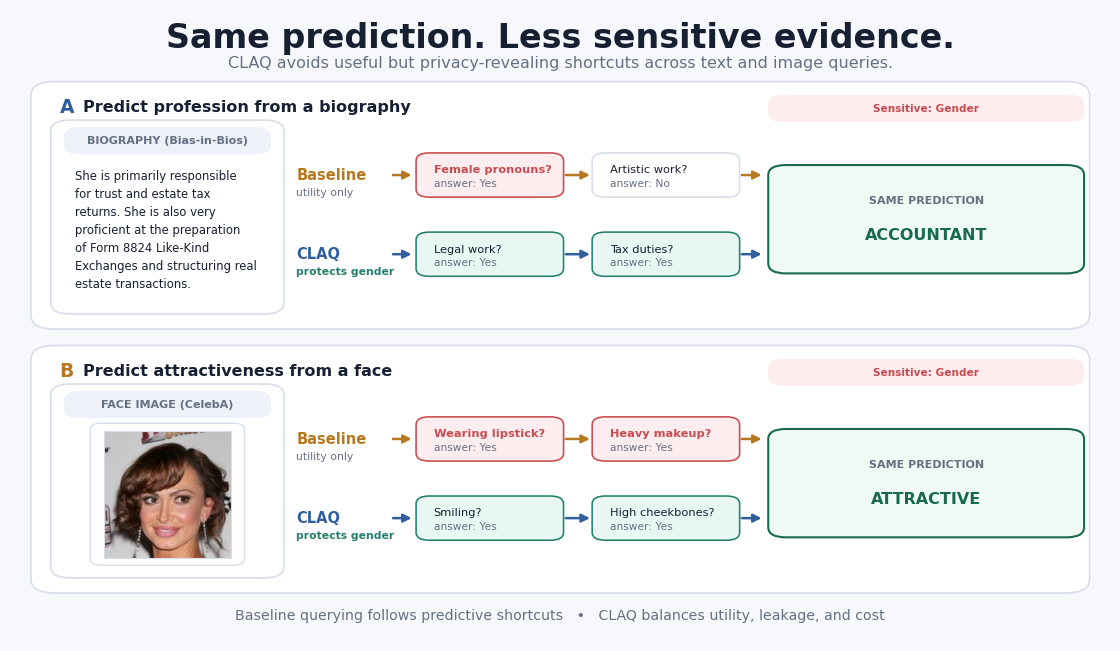

In [11]:
# Visual system
C_BG = "#F7F8FC"
C_INK = "#172033"
C_MUTED = "#667085"
C_BORDER = "#D7DDEA"
C_BASE = "#B7791F"
C_BASE_LIGHT = "#FFF6DD"
C_CLAQ = "#315E9E"
C_CLAQ_LIGHT = "#EAF2FF"
C_LEAK = "#C84B50"
C_LEAK_LIGHT = "#FDEDEE"
C_SAFE = "#25806B"
C_SAFE_LIGHT = "#E9F7F2"
C_RESULT = "#186A4E"

FIG_W, FIG_H = 14.2, 8.2

# Every rounded box grows by PAD on each side (matplotlib boxstyle padding).
# All spacing below accounts for it so boxes never touch and arrows stay visible.
PAD = 0.006


def color_accent(modality):
    return C_CLAQ if modality == "text" else C_BASE


def rounded_box(ax, x, y, w, h, *, face="white", edge=C_BORDER, radius=0.015, lw=1.2, z=1):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad={PAD},rounding_size={radius}",
        facecolor=face, edgecolor=edge, linewidth=lw, zorder=z,
    )
    ax.add_patch(patch)
    return patch


def pill(ax, x, y, text, *, face, color, width=None, fontsize=9, z=5):
    width = width or max(0.058, 0.0082 * len(text) + 0.020)
    rounded_box(ax, x, y, width, 0.031, face=face, edge=face, radius=0.014, lw=0, z=z)
    ax.text(x + width / 2, y + 0.0155, text, ha="center", va="center",
            fontsize=fontsize, color=color, fontweight="bold", zorder=z + 1)
    return width


CHIP_W, CHIP_H = 0.122, 0.058


def query_chip(ax, x, y, question, answer, *, sensitive=False, claq=False):
    w, h = CHIP_W, CHIP_H
    if sensitive:
        face, edge, qcolor = C_LEAK_LIGHT, C_LEAK, C_LEAK
    elif claq:
        face, edge, qcolor = C_SAFE_LIGHT, C_SAFE, C_INK
    else:
        face, edge, qcolor = "white", C_BORDER, C_INK
    rounded_box(ax, x, y, w, h, face=face, edge=edge, radius=0.012, lw=1.15, z=5)
    ax.text(x + 0.010, y + 0.037, question, ha="left", va="center",
            fontsize=8.2, color=qcolor, fontweight="bold" if sensitive else "normal", zorder=6)
    ax.text(x + 0.010, y + 0.015, f"answer: {answer}", ha="left", va="center",
            fontsize=7.7, color=C_MUTED, zorder=6)
    return w


def arrow(ax, x0, y0, x1, y1, color, *, lw=2.0, z=3):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                shrinkA=0, shrinkB=0, mutation_scale=12), zorder=z)


def _square_crop(img):
    h_img, w_img = img.shape[:2]
    side = min(h_img, w_img)
    top = int((h_img - side) * 0.42)  # bias slightly toward the face
    left = (w_img - side) // 2
    return img[top:top + side, left:left + side]


def draw_input_card(ax, x, y, w, h, example, modality):
    rounded_box(ax, x, y, w, h, face="white", edge=C_BORDER, radius=0.018)
    label = "BIOGRAPHY (Bias-in-Bios)" if modality == "text" else "FACE IMAGE (CelebA)"
    label_y = y + h - 0.042
    pill(ax, x + 0.012, label_y, label, face="#EEF1F7", color=C_MUTED,
         fontsize=8.0, width=w - 0.024)
    if modality == "text":
        wrapped = textwrap.fill(example["bio"], width=31)
        text_mid = ((label_y - 0.020) + (y + 0.020)) / 2
        ax.text(x + 0.016, text_mid, wrapped, ha="left", va="center",
                fontsize=8.4, color=C_INK, linespacing=1.5, zorder=4)
    else:
        img = _square_crop(plt.imread(example["image_path"]))
        aspect = ax.figure.get_figwidth() / ax.figure.get_figheight()
        # Fit the largest visually-square image that leaves room for the label.
        top_limit = label_y - 0.026
        bot_limit = y + 0.026
        img_h = top_limit - bot_limit
        img_w = img_h / aspect
        max_w = w - 0.030
        if img_w > max_w:
            img_w, img_h = max_w, max_w * aspect
        img_x = x + (w - img_w) / 2
        img_y = bot_limit + (top_limit - bot_limit - img_h) / 2
        rounded_box(ax, img_x - 0.006, img_y - 0.006, img_w + 0.012, img_h + 0.012,
                    face="white", edge=C_BORDER, radius=0.010, lw=1.0, z=3)
        iax = ax.inset_axes([img_x, img_y, img_w, img_h], zorder=4)
        iax.imshow(img)
        iax.set_xticks([]); iax.set_yticks([])
        for spine in iax.spines.values():
            spine.set_edgecolor(C_BORDER)


# Fixed horizontal layout (data coords). Gaps account for the box padding (PAD)
# so adjacent boxes never touch and every connector arrow stays visible.
LABEL_X = 0.260
ARROW0_X0, ARROW0_X1 = 0.348, 0.365
CHIP_XS = [0.375, 0.535]


def draw_query_path(ax, y, queries, *, claq):
    color = C_CLAQ if claq else C_BASE
    ax.text(LABEL_X, y + 0.010, "CLAQ" if claq else "Baseline",
            ha="left", va="center", fontsize=10.5, color=color, fontweight="bold", zorder=5)
    ax.text(LABEL_X, y - 0.018, "protects gender" if claq else "utility only",
            ha="left", va="center", fontsize=7.8,
            color=C_SAFE if claq else C_MUTED,
            fontweight="bold" if claq else "normal", zorder=5)
    arrow(ax, ARROW0_X0, y + 0.010, ARROW0_X1, y + 0.010, color, lw=1.8)
    for i, (question, answer, sensitive) in enumerate(queries):
        query_chip(ax, CHIP_XS[i], y - 0.019, question, answer,
                   sensitive=sensitive, claq=claq)
        if i < len(queries) - 1:
            arrow(ax, CHIP_XS[i] + CHIP_W + PAD + 0.002, y + 0.010,
                  CHIP_XS[i + 1] - PAD - 0.002, y + 0.010, color, lw=1.8)
    return color


RESULT_X, RESULT_W = 0.695, 0.275


def draw_row(ax, y, h, example, modality, row_number):
    rounded_box(ax, 0.025, y, 0.950, h, face="white", edge=C_BORDER, radius=0.022, lw=1.2)
    ax.text(0.045, y + h - 0.034, f"{row_number}", fontsize=13.5, color=color_accent(modality),
            fontweight="bold", va="center", zorder=4)
    ax.text(0.066, y + h - 0.034, example['task'],
            fontsize=11.5, color=C_INK, fontweight="bold", va="center", zorder=4)
    pill(ax, RESULT_X, y + h - 0.052, f"Sensitive: {example['protected']}",
         face=C_LEAK_LIGHT, color=C_LEAK, fontsize=7.6, width=RESULT_W)

    card_y, card_h = y + 0.024, h - 0.085
    draw_input_card(ax, 0.043, card_y, 0.200, card_h, example, modality)

    baseline_y = y + h * 0.60
    claq_y = y + h * 0.27
    base_color = draw_query_path(ax, baseline_y, example["baseline_queries"], claq=False)
    claq_color = draw_query_path(ax, claq_y, example["claq_queries"], claq=True)

    result_h = h * 0.42
    result_y = y + (h - 0.088 - result_h) / 2 + 0.022
    rounded_box(ax, RESULT_X, result_y, RESULT_W, result_h,
                face="#EFFAF4", edge=C_RESULT, radius=0.016, lw=1.5, z=4)
    ax.text(RESULT_X + RESULT_W / 2, result_y + result_h * 0.68, "SAME PREDICTION",
            ha="center", va="center", fontsize=8.0, color=C_MUTED,
            fontweight="bold", zorder=6)
    ax.text(RESULT_X + RESULT_W / 2, result_y + result_h * 0.34, example["target"],
            ha="center", va="center", fontsize=11.5, color=C_RESULT,
            fontweight="bold", zorder=6)
    res_left = RESULT_X - PAD - 0.006
    path_right = CHIP_XS[-1] + CHIP_W + PAD + 0.002
    arrow(ax, path_right, baseline_y + 0.010, res_left, baseline_y + 0.010,
          base_color, lw=1.8)
    arrow(ax, path_right, claq_y + 0.010, res_left, claq_y + 0.010,
          claq_color, lw=1.8)


def make_hero_figure(bios_example=None, celeba_example=None, *, variant="readme"):
    """Render either a banner-style README figure or a compact paper figure."""
    if variant not in {"readme", "paper"}:
        raise ValueError("variant must be 'readme' or 'paper'")

    bios_example = bios_example or BIOS_EXAMPLE
    celeba_example = celeba_example or CELEBA_EXAMPLE
    is_readme = variant == "readme"
    fig_height = FIG_H if is_readme else 6.9
    fig, ax = plt.subplots(figsize=(FIG_W, fig_height), facecolor=C_BG)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    if is_readme:
        ax.text(0.5, 0.955, "Same prediction. Less sensitive evidence.",
                ha="center", va="center", fontsize=24, color=C_INK, fontweight="bold")
        ax.text(0.5, 0.916,
                "CLAQ avoids useful but privacy-revealing shortcuts across text and image queries.",
                ha="center", va="center", fontsize=11.5, color=C_MUTED)
        row_specs = ((0.500, 0.380), (0.082, 0.380))
    else:
        row_specs = ((0.525, 0.430), (0.045, 0.430))

    draw_row(ax, *row_specs[0], bios_example, "text", "A")
    draw_row(ax, *row_specs[1], celeba_example, "image", "B")

    if is_readme:
        ax.text(0.5, 0.040,
                "Baseline querying follows predictive shortcuts   •   CLAQ balances utility, leakage, and cost",
                ha="center", va="center", fontsize=10.2, color=C_MUTED)
    return fig


fig = make_hero_figure(variant="readme")
plt.show()

In [12]:
# Export a compact paper figure and a banner-style README figure.
EXPORTS = {
    "paper": OUTPUT_DIR / "claq_two_modalities_paper",
    "readme": OUTPUT_DIR / "claq_two_modalities_readme",
}

for variant, output_stem in EXPORTS.items():
    fig = make_hero_figure(variant=variant)
    for suffix, kwargs in {
        ".svg": {},
        # ".pdf": {},
        # ".png": {"dpi": 180},
    }.items():
        output_path = output_stem.with_suffix(suffix)
        fig.savefig(output_path, bbox_inches="tight", facecolor=C_BG, **kwargs)
        print(f"Saved: {output_path}")
    plt.close(fig)

Saved: /Users/amir.atashin/Projects/claq/artifacts/figures/claq_two_modalities_paper.svg
Saved: /Users/amir.atashin/Projects/claq/artifacts/figures/claq_two_modalities_readme.svg


## Paper-use note

The biography, face, and query sequences are intentionally illustrative. The figure should therefore be described as an **intuition figure**, not as a qualitative experimental result.

Suggested caption:

> **Same prediction, different evidence.** A utility-focused questioner can exploit gender-revealing shortcuts in both text and image domains. CLAQ instead balances predictive utility, protected-attribute leakage, and query cost, reaching the same prediction through a less revealing query path.

Before final publication, the wording and visual concepts can be refined without claiming that these exact paths were observed in a rollout.